# Analysis

In [ ]:
!pip install torch numpy matplotlib seaborn pandas


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

In [ ]:
# print device
import torch
taus = torch.randn(3, 32, 64)
# m = torch.bmm(taus, taus.transpose(1, 2)).sum(dim=0) # memory intensive
m = torch.einsum("nik,njk->ij", taus, taus)
u, s, vt = torch.linalg.svd(m, full_matrices=False)
q_star_prm = u @ vt
(q_star_prm @ taus).mean(dim=0).shape

torch.Size([32, 64])

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_head, bias=False):
        super().__init__()
        assert d_model % n_head == 0
        self.d_model = d_model
        self.n_head = n_head
        self.d_k = d_model // n_head

        # Wq + Wk: each (n_head * d_k, d_model) = (d_model, d_model)
        # total: (2 * d_model, d_model)
        self.qk = nn.Linear(d_model, 2 * d_model, bias=bias)

        # Wv: (n_head * d_k, d_model) = (d_model, d_model)
        # Wo: (d_model, n_head * d_k) = (d_model, d_model)
        # total: (2 * d_model, d_model)
        self.vot = nn.Linear(d_model, 2 * d_model, bias=bias)

    def forward(self, query, key, value, attn_mask=None, key_padding_mask=None):
        seq_len, batch, _ = query.shape
        d = self.d_model

        # Extract flat weight matrices
        Wq = self.qk.weight[:d]          # (d_model, d_model)
        Wk = self.qk.weight[d:]          # (d_model, d_model)
        Wv = self.vot.weight[:d]          # (d_model, d_model)
        Wo = self.vot.weight[d:].T        # (d_model, d_model)

        bq = bk = bv = bo = None
        if self.qk.bias is not None:
            bq, bk = self.qk.bias[:d], self.qk.bias[d:]
            bv, bo = self.vot.bias[:d], self.vot.bias[d:]

        # Q, K, V projections
        Q = F.linear(query, Wq, bq)     # (seq, batch, d_model)
        K = F.linear(key, Wk, bk)
        V = F.linear(value, Wv, bv)

        # Reshape into heads: (batch, n_head, seq, d_k)
        Q = Q.view(seq_len, batch, self.n_head, self.d_k).permute(1, 2, 0, 3)
        K = K.view(K.size(0), batch, self.n_head, self.d_k).permute(1, 2, 0, 3)
        V = V.view(V.size(0), batch, self.n_head, self.d_k).permute(1, 2, 0, 3)

        # Attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if attn_mask is not None:
            scores = scores + attn_mask

        if key_padding_mask is not None:
            scores = scores.masked_fill(
                key_padding_mask.unsqueeze(1).unsqueeze(2), float('-inf')
            )

        attn_weights = F.softmax(scores, dim=-1)
        context = torch.matmul(attn_weights, V)  # (batch, n_head, seq, d_k)

        # Collapse heads: (seq, batch, d_model)
        context = context.permute(2, 0, 1, 3).contiguous().view(seq_len, batch, d)

        # Output projection
        output = F.linear(context, Wo, bo)

        attn_weights_avg = attn_weights.mean(dim=1)
        return output, attn_weights_avg


def copy_weights_from_pytorch_mha(pt_mha, custom_mha):
    d = custom_mha.d_model
    with torch.no_grad():
        custom_mha.qk.weight[:d].copy_(pt_mha.in_proj_weight[:d])
        custom_mha.qk.weight[d:].copy_(pt_mha.in_proj_weight[d:2*d])
        custom_mha.vot.weight[:d].copy_(pt_mha.in_proj_weight[2*d:])
        custom_mha.vot.weight[d:].T.copy_(pt_mha.out_proj.weight)

        if pt_mha.in_proj_bias is not None:
            custom_mha.qk.bias[:d].copy_(pt_mha.in_proj_bias[:d])
            custom_mha.qk.bias[d:].copy_(pt_mha.in_proj_bias[d:2*d])
            custom_mha.vot.bias[:d].copy_(pt_mha.in_proj_bias[2*d:])
            custom_mha.vot.bias[d:].copy_(pt_mha.out_proj.bias)


def copy_weights_to_pytorch_mha(custom_mha, pt_mha):
    d = custom_mha.d_model
    with torch.no_grad():
        pt_mha.in_proj_weight[:d].copy_(custom_mha.qk.weight[:d])
        pt_mha.in_proj_weight[d:2*d].copy_(custom_mha.qk.weight[d:])
        pt_mha.in_proj_weight[2*d:].copy_(custom_mha.vot.weight[:d])
        pt_mha.out_proj.weight.copy_(custom_mha.vot.weight[d:].T)

        if pt_mha.in_proj_bias is not None:
            pt_mha.in_proj_bias[:d].copy_(custom_mha.qk.bias[:d])
            pt_mha.in_proj_bias[d:2*d].copy_(custom_mha.qk.bias[d:])
            pt_mha.in_proj_bias[2*d:].copy_(custom_mha.vot.bias[:d])
            pt_mha.out_proj.bias.copy_(custom_mha.vot.bias[d:])


# --- Tests ---
torch.manual_seed(42)
d_model, n_head = 768, 4

for use_bias in [False, True]:
    print(f"\n{'='*50}")
    print(f"bias={use_bias}")
    print(f"{'='*50}")

    pt_mha = nn.MultiheadAttention(d_model, n_head, bias=use_bias)
    custom_mha = MultiHeadAttention(d_model, n_head, bias=use_bias)
    copy_weights_from_pytorch_mha(pt_mha, custom_mha)
    pt_mha.eval()
    custom_mha.eval()

    x = torch.randn(10, 2, d_model)

    # --- Test: PyTorch -> Custom ---
    print("\n--- PyTorch -> Custom ---")

    pt_out, pt_attn = pt_mha(x, x, x, need_weights=True, average_attn_weights=True)
    custom_out, custom_attn = custom_mha(x, x, x)
    print(f"Self-attention:      {torch.allclose(pt_out, custom_out, atol=1e-6)}")

    q = torch.randn(5, 2, d_model)
    kv = torch.randn(12, 2, d_model)
    pt_out2, _ = pt_mha(q, kv, kv)
    custom_out2, _ = custom_mha(q, kv, kv)
    print(f"Cross-attention:     {torch.allclose(pt_out2, custom_out2, atol=1e-6)}")

    causal_mask = nn.Transformer.generate_square_subsequent_mask(10)
    pt_out3, _ = pt_mha(x, x, x, attn_mask=causal_mask)
    custom_out3, _ = custom_mha(x, x, x, attn_mask=causal_mask)
    print(f"Causal attention:    {torch.allclose(pt_out3, custom_out3, atol=1e-6)}")

    kpm = torch.zeros(2, 10, dtype=torch.bool)
    kpm[0, 7:] = True
    pt_out4, _ = pt_mha(x, x, x, key_padding_mask=kpm)
    custom_out4, _ = custom_mha(x, x, x, key_padding_mask=kpm)
    print(f"Key padding mask:    {torch.allclose(pt_out4, custom_out4, atol=1e-6)}")

    # --- Test: Custom -> PyTorch ---
    print("\n--- Custom -> PyTorch ---")

    custom_mha2 = MultiHeadAttention(d_model, n_head, bias=use_bias)
    pt_mha2 = nn.MultiheadAttention(d_model, n_head, bias=use_bias)
    copy_weights_to_pytorch_mha(custom_mha2, pt_mha2)
    custom_mha2.eval()
    pt_mha2.eval()

    pt_out5, _ = pt_mha2(x, x, x, need_weights=True, average_attn_weights=True)
    custom_out5, _ = custom_mha2(x, x, x)
    print(f"Self-attention:      {torch.allclose(pt_out5, custom_out5, atol=1e-6)}")

    pt_out6, _ = pt_mha2(q, kv, kv)
    custom_out6, _ = custom_mha2(q, kv, kv)
    print(f"Cross-attention:     {torch.allclose(pt_out6, custom_out6, atol=1e-6)}")

    pt_out7, _ = pt_mha2(x, x, x, attn_mask=causal_mask)
    custom_out7, _ = custom_mha2(x, x, x, attn_mask=causal_mask)
    print(f"Causal attention:    {torch.allclose(pt_out7, custom_out7, atol=1e-6)}")

    pt_out8, _ = pt_mha2(x, x, x, key_padding_mask=kpm)
    custom_out8, _ = custom_mha2(x, x, x, key_padding_mask=kpm)
    print(f"Key padding mask:    {torch.allclose(pt_out8, custom_out8, atol=1e-6)}")

    # --- Test: Roundtrip PyTorch -> Custom -> PyTorch ---
    print("\n--- Roundtrip: PT -> Custom -> PT ---")

    pt_mha3 = nn.MultiheadAttention(d_model, n_head, bias=use_bias)
    custom_mha3 = MultiHeadAttention(d_model, n_head, bias=use_bias)
    pt_mha4 = nn.MultiheadAttention(d_model, n_head, bias=use_bias)

    copy_weights_from_pytorch_mha(pt_mha3, custom_mha3)
    copy_weights_to_pytorch_mha(custom_mha3, pt_mha4)

    print(f"in_proj_weight:      {torch.allclose(pt_mha3.in_proj_weight, pt_mha4.in_proj_weight)}")
    print(f"out_proj.weight:     {torch.allclose(pt_mha3.out_proj.weight, pt_mha4.out_proj.weight)}")
    if use_bias:
        print(f"in_proj_bias:        {torch.allclose(pt_mha3.in_proj_bias, pt_mha4.in_proj_bias)}")
        print(f"out_proj.bias:       {torch.allclose(pt_mha3.out_proj.bias, pt_mha4.out_proj.bias)}")

    pt_p = sum(p.numel() for p in pt_mha.parameters())
    cu_p = sum(p.numel() for p in custom_mha.parameters())
    print(f"\nParam count match:   {pt_p == cu_p}")

print("\nParameters:")
for n, p in custom_mha.named_parameters():
    print(f"  {n}: {p.shape}")


bias=False

--- PyTorch -> Custom ---
Self-attention:      True
Cross-attention:     True
Causal attention:    True
Key padding mask:    True

--- Custom -> PyTorch ---
Self-attention:      True
Cross-attention:     True
Causal attention:    True
Key padding mask:    True

--- Roundtrip: PT -> Custom -> PT ---
in_proj_weight:      True
out_proj.weight:     True

Param count match:   True

bias=True

--- PyTorch -> Custom ---
Self-attention:      True
Cross-attention:     True
Causal attention:    True
Key padding mask:    True

--- Custom -> PyTorch ---
Self-attention:      True
Cross-attention:     True
Causal attention:    True
Key padding mask:    True

--- Roundtrip: PT -> Custom -> PT ---
in_proj_weight:      True
out_proj.weight:     True
in_proj_bias:        True
out_proj.bias:       True

Param count match:   True

Parameters:
  qk.weight: torch.Size([1536, 768])
  qk.bias: torch.Size([1536])
  vot.weight: torch.Size([1536, 768])
  vot.bias: torch.Size([1536])


## Interference vs α

In [ ]:
model = "ViT-B-16"
results_dir = f"../results/{model}"

# Load all cached interference files
files = sorted(glob.glob(f"{results_dir}/interference_alpha*.npz"))
print(f"Found {len(files)} cached files")

alphas = []
totals = []
for f in files:
    data = np.load(f, allow_pickle=True)
    alpha = float(data["alpha"])
    interference = dict(data["interference"].item())
    alphas.append(alpha)
    totals.append(sum(interference.values()))

# Sort by alpha
order = np.argsort(alphas)
alphas = np.array(alphas)[order]
totals = np.array(totals)[order]

print(f"Alphas: {alphas}")
print(f"Total interference: {totals}")

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(alphas, totals, "o-", linewidth=2, markersize=5)
ax.set_xlabel(r"$\alpha$", fontsize=14)
ax.set_ylabel(r"Total Interference $\mathcal{L}$", fontsize=14)
ax.set_title(f"Interference vs scaling coefficient ({model})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{results_dir}/interference_vs_alpha.png", dpi=150, bbox_inches="tight")
plt.show()

## Decorrelation


$ρ(\|a[l-1]\|^2 \;, \|g[l]\|^2)$

### Decorrelation b/w norms

In [ ]:
import numpy as np
import os

model = "ViT-B-16"
results_dir = f"../results/{model}"
tasks = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]

rows = []

ignore_list = ["ln_", "ls_", "conv", "patch_dropout"]

for task in tasks:
    path = f"{results_dir}/decorrelation_norm_{task}.npz"
    if not os.path.exists(path):
        print(f"Skipping {task} (not found)")
        continue

    data = np.load(path)
    # layer_names = sorted(set(k.replace("g_sq/", "") for k in data.files if k.startswith("g_sq/")))

    layer_names = sorted(set(k.replace("g_sq/", "") for k in data.files if k.startswith("g_sq/")))
    layer_names = [n for n in layer_names if not any(ig in n for ig in ignore_list)]

    rhos = []
    for i in range(1, len(layer_names)):
        a_prev = data[f"a_sq/{layer_names[i-1]}"]
        g_curr = data[f"g_sq/{layer_names[i]}"]
        if a_prev.std() > 0 and g_curr.std() > 0:
            rhos.append(np.corrcoef(a_prev, g_curr)[0, 1])
        else:
            rhos.append(0.0)

    rhos = np.array(rhos)
    rows.append({
        "task": task,
        "mean": np.mean(np.abs(rhos)),
        "median": np.median(np.abs(rhos)),
        "max": np.max(np.abs(rhos)),
        "pct_01": 100 * np.mean(np.abs(rhos) < 0.1),
        "pct_03": 100 * np.mean(np.abs(rhos) < 0.3),
        "n_pairs": len(rhos),
    })

# Print summary table
print(f"{'Task':<12} {'Mean|ρ|':>8} {'Med|ρ|':>8} {'Max|ρ|':>8} {'<0.1':>6} {'<0.3':>6} {'pairs':>6}")
print("-" * 56)
for r in rows:
    print(f"{r['task']:<12} {r['mean']:>8.2f} {r['median']:>8.2f} {r['max']:>8.2f} {r['pct_01']:>5.1f}% {r['pct_03']:>5.0f}% {r['n_pairs']:>6}")

# {r['pct_03']:>5.1f}% 
# make just int {r['pct_03']:>5.1f}%  --> {r['pct_03']:>5.0f}%
# Aggregate
all_means = [r["mean"] for r in rows]
all_maxes = [r["max"] for r in rows]
print("-" * 56)
print(f"{'Overall':<12} {np.mean(all_means):>8.2f} {'':>8} {np.max(all_maxes):>8.2f}")

Task          Mean|ρ|   Med|ρ|   Max|ρ|   <0.1   <0.3  pairs
--------------------------------------------------------
Cars             0.05     0.03     0.16  90.4%   100%     73
DTD              0.05     0.05     0.17  91.8%   100%     73
EuroSAT          0.03     0.02     0.10  98.6%   100%     73
GTSRB            0.01     0.01     0.07 100.0%   100%     73
MNIST            0.02     0.01     0.07 100.0%   100%     73
RESISC45         0.04     0.03     0.16  97.3%   100%     73
SUN397           0.04     0.03     0.19  86.3%   100%     73
SVHN             0.06     0.05     0.16  74.0%   100%     73
--------------------------------------------------------
Overall          0.04              0.19


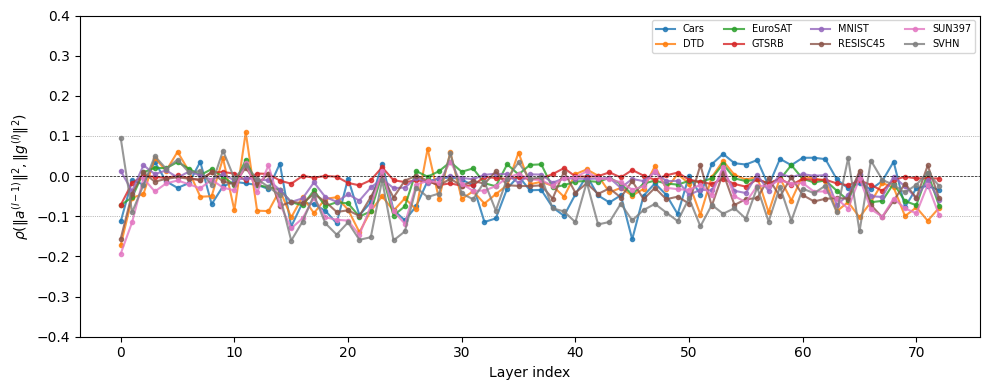

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import os

model = "ViT-B-16"
results_dir = f"../results/{model}"
tasks = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]
ignore_list = ["ln_", "ls_", "conv", "patch_dropout"]

fig, ax = plt.subplots(figsize=(10, 4))

for task in tasks:
    path = f"{results_dir}/decorrelation_{task}.npz"
    if not os.path.exists(path):
        continue

    data = np.load(path)
    layer_names = sorted(set(k.replace("g_sq/", "") for k in data.files if k.startswith("g_sq/")))
    layer_names = [n for n in layer_names if not any(ig in n for ig in ignore_list)]

    rhos = []
    for i in range(1, len(layer_names)):
        a_prev = data[f"a_sq/{layer_names[i-1]}"]
        g_curr = data[f"g_sq/{layer_names[i]}"]
        if a_prev.std() > 0 and g_curr.std() > 0:
            rhos.append(np.corrcoef(a_prev, g_curr)[0, 1])
        else:
            rhos.append(0.0)

    ax.plot(range(len(rhos)), rhos, marker="o", markersize=3, label=task, alpha=0.8)

ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.axhline(0.1, color="gray", linewidth=0.5, linestyle=":")
ax.axhline(-0.1, color="gray", linewidth=0.5, linestyle=":")
ax.set_xlabel("Layer index")
ax.set_ylabel(r"$\rho(\|a^{(l-1)}\|^2, \|g^{(l)}\|^2)$")
ax.legend(fontsize=7, ncol=4, loc="upper right")
ax.set_ylim(-0.4, 0.4)
fig.tight_layout()
plt.savefig(f"{results_dir}/decorrelation_rho_per_layer.pdf", bbox_inches="tight")
plt.show()

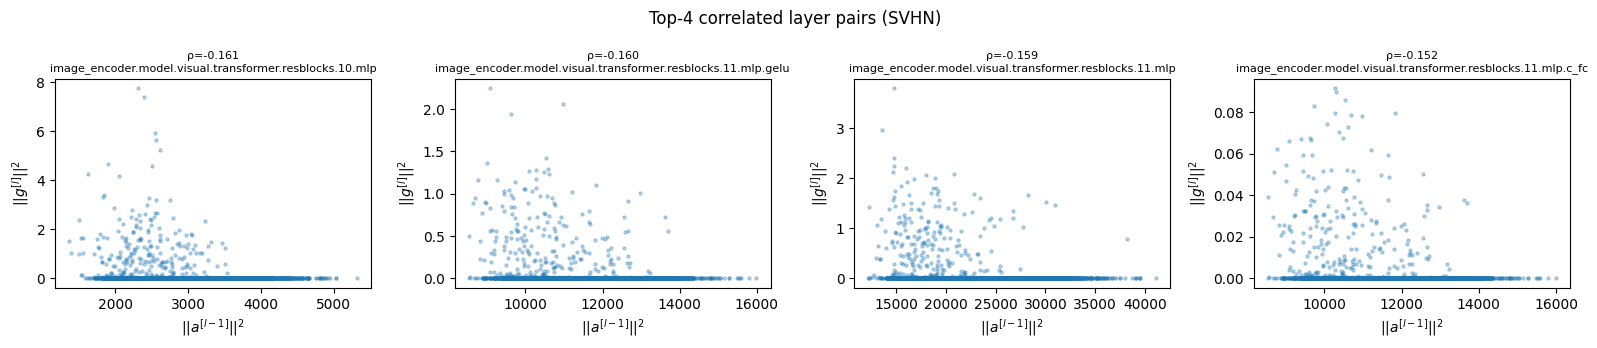

In [ ]:
# Scatter plots for a few selected layer pairs (highest |ρ|)
top_k = 4
top_idx = np.argsort(np.abs(rhos))[-top_k:][::-1]


fig, axes = plt.subplots(1, top_k, figsize=(4 * top_k, 3.5))
for ax, idx_l in zip(axes, top_idx):
    a_prev = data[f"a_sq/{layer_names[idx_l]}"]
    g_curr = data[f"g_sq/{layer_names[idx_l+1]}"]
    ax.scatter(a_prev, g_curr, alpha=0.3, s=5)
    ax.set_xlabel(r"$||a^{[l-1]}||^2$", fontsize=10)
    ax.set_ylabel(r"$||g^{[l]}||^2$", fontsize=10)
    ax.set_title(f"ρ={rhos[idx_l]:.3f}\n{layer_names[idx_l+1]}", fontsize=8)
plt.suptitle(f"Top-{top_k} correlated layer pairs ({task})", fontsize=12)
plt.tight_layout()
plt.savefig(f"{results_dir}/decorrelation_scatter_{task}.png", dpi=150, bbox_inches="tight")
plt.show()

### Decorellation

\begin{tabular}{lrr}
\toprule
 & mean & max \\
task &  &  \\
\midrule
Cars & 0.03 & 0.16 \\
DTD & 0.04 & 0.23 \\
EuroSAT & 0.02 & 0.12 \\
GTSRB & 0.01 & 0.11 \\
MNIST & 0.01 & 0.07 \\
RESISC45 & 0.02 & 0.16 \\
SUN397 & 0.02 & 0.18 \\
SVHN & 0.02 & 0.12 \\
\bottomrule
\end{tabular}



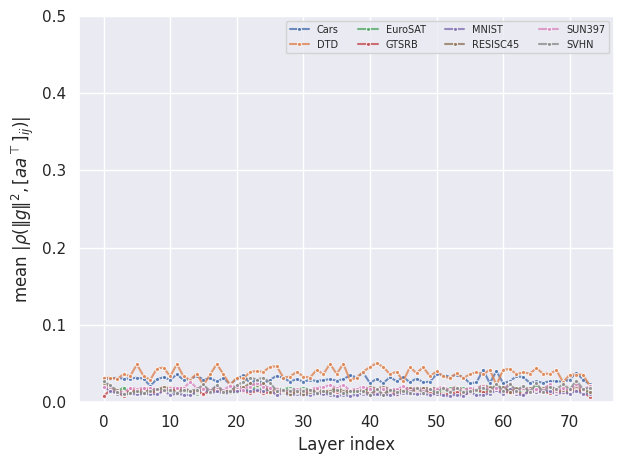

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

sns.set_theme()

model = "ViT-B-16"
results_dir = f"../results/{model}"
tasks = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]
ignore = ["ln_", "ls_", "conv", "patch_dropout"]

corr = lambda x, y: np.corrcoef(x, y)[0, 1] if x.std() > 0 and y.std() > 0 else 0.0

rows = []
for task in tasks:
    path = f"{results_dir}/decorrelation_{task}.npz"
    if not os.path.exists(path):
        continue
    data = np.load(path)
    layers = sorted(k[5:] for k in data.files if k.startswith("g_sq/")) # remove key's prefix
    layers = [l for l in layers if not any(ig in l for ig in ignore)]

    for idx_l, l in enumerate(layers):
        g, aat = data[f"g_sq/{l}"], data[f"aat_samples/{l}"]
        # For each layer we have N_indices (i,j). For each (i,j) we have N_samples of [g]_i and [aat]_{ij}
        # thus we compute the correlation for each (i,j) and take the average over the N_indices
        rhos = np.abs([corr(g, aat[:, k]) for k in range(aat.shape[1])])  # [N_samples, N_indices]
        rows.append({"task": task, "layer_idx": idx_l, "layer": l, "mean_rho": rhos.mean(), "max_rho": rhos.max()})

df = pd.DataFrame(rows)

# ── Table ──
summary = df.groupby("task").agg(mean=("mean_rho", "mean"), median=("mean_rho", "median"), max=("max_rho", "max"))
summary["<.1"] = df.groupby("task")["mean_rho"].apply(lambda x: f"{100*(x<.1).mean():.0f}%")
summary["<.3"] = df.groupby("task")["mean_rho"].apply(lambda x: f"{100*(x<.3).mean():.0f}%")
# print(summary.round(2).to_latex())
print(summary[['mean', 'max']].round(2).to_latex(float_format=lambda x: f"{x:.2f}"))

# ── Plot ──
sns.lineplot(data=df, x="layer_idx", y="mean_rho", hue="task", marker="o", markersize=3, alpha=0.8)
# plt.axhline(0.1, color="gray", lw=0.5, ls=":")
# plt.axhline(0.3, color="gray", lw=0.5, ls=":")
plt.ylim(0, 0.5)
plt.xlabel("Layer index")
plt.ylabel(r"mean $|\rho(\|g\|^2, [aa^\top]_{ij})|$")
# plt.title(f"{model}: Activation–gradient decorrelation")
plt.legend(fontsize=7, ncol=4)
plt.tight_layout()
plt.savefig(f"{results_dir}/decorrelation_aat_per_layer.pdf", bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

sns.set_theme()

model = "ViT-B-16"
results_dir = f"../results/{model}"
tasks = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]
ignore = ["ln_", "ls_", "conv", "patch_dropout"]

corr = lambda x, y: np.corrcoef(x, y)[0, 1] if x.std() > 0 and y.std() > 0 else 0.0

rows = []
for task in tasks:
    path = f"{results_dir}/decorrelation_{task}.npz"
    if not os.path.exists(path):
        continue
    data = np.load(path)
    layers = sorted(k[5:] for k in data.files if k.startswith("g_sq/")) # remove key's prefix
    layers = [l for l in layers if not any(ig in l for ig in ignore)]

    for idx_l, l in enumerate(layers):
        # (N_samples,), (N_samples, N_indices)
        g, aat = data[f"g_sq/{l}"], data[f"aat_samples/{l}"]
        N_samples, N_indices = aat.shape
        for idx_i in range(N_indices):
            rho = np.abs(corr(g, aat[:, idx_i]))  # (1,)
            rows.append({'task': task, 'layer': l, 'layer_idx': idx_l, 'entry_idx': idx_i, 'rho': rho})
df = pd.DataFrame(rows)
sns.relplot(data=df, x="layer_idx", y="rho", hue="task", marker="o",  alpha=0.8)

       task                                              layer  layer_idx  \
0      Cars                         image_encoder.model.visual          0   
1      Cars                         image_encoder.model.visual          0   
2      Cars                         image_encoder.model.visual          0   
3      Cars                         image_encoder.model.visual          0   
4      Cars                         image_encoder.model.visual          0   
...     ...                                                ...        ...   
18939  SVHN  image_encoder.model.visual.transformer.resbloc...         73   
18940  SVHN  image_encoder.model.visual.transformer.resbloc...         73   
18941  SVHN  image_encoder.model.visual.transformer.resbloc...         73   
18942  SVHN  image_encoder.model.visual.transformer.resbloc...         73   
18943  SVHN  image_encoder.model.visual.transformer.resbloc...         73   

       entry_idx       rho  
0              0  0.016917  
1              1 

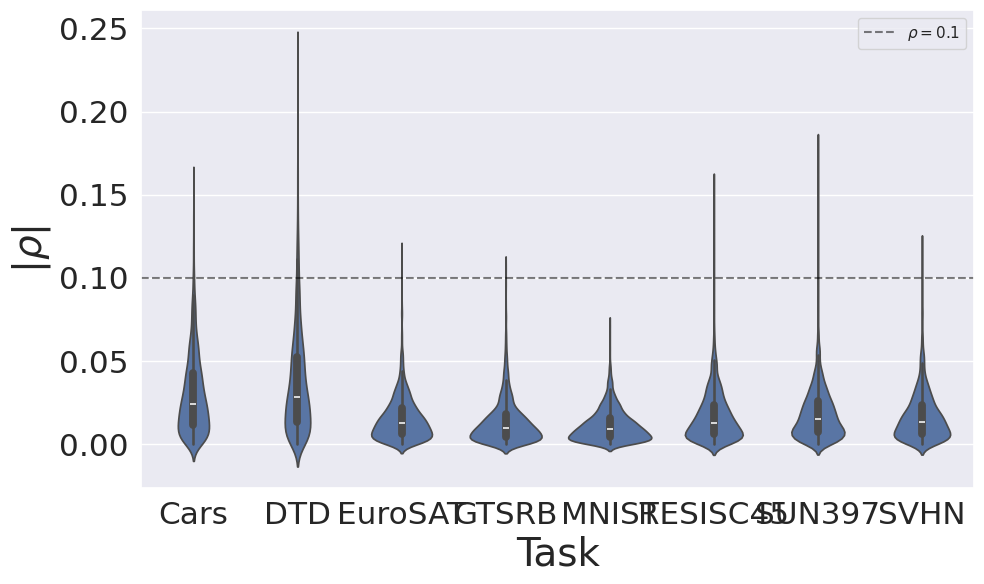


Summary Statistics (all points):
           mean    std    50%    max
task                                
Cars      0.030  0.024  0.024  0.157
DTD       0.037  0.032  0.028  0.235
EuroSAT   0.015  0.013  0.012  0.116
GTSRB     0.013  0.013  0.010  0.107
MNIST     0.011  0.010  0.009  0.072
RESISC45  0.017  0.015  0.013  0.156
SUN397    0.018  0.015  0.015  0.180
SVHN      0.017  0.015  0.013  0.119

Overall mean |ρ|: 0.020
% of all correlations < 0.1: 99.2%


In [ ]:
# sns.relplot(data=df, x="layer_idx", y="rho", hue="task", marker="o",  alpha=0.8)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

sns.set_theme()
BASE_FONTSIZE=28

model = "ViT-B-16"
results_dir = f"../results/{model}"
tasks = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]
ignore = ["ln_", "ls_", "conv", "patch_dropout"]

corr = lambda x, y: np.corrcoef(x, y)[0, 1] if x.std() > 0 and y.std() > 0 else 0.0

rows = []
for task in tasks:
    path = f"{results_dir}/decorrelation_{task}.npz"
    if not os.path.exists(path):
        continue
    data = np.load(path)
    layers = sorted(k[5:] for k in data.files if k.startswith("g_sq/"))
    layers = [l for l in layers if not any(ig in l for ig in ignore)]

    for idx_l, l in enumerate(layers):
        g, aat = data[f"g_sq/{l}"], data[f"aat_samples/{l}"]
        N_samples, N_indices = aat.shape
        for idx_i in range(N_indices):
            rho = np.abs(corr(g, aat[:, idx_i]))
            rows.append({'task': task, 'layer': l, 'layer_idx': idx_l, 'entry_idx': idx_i, 'rho': rho})

df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df, x="task", y="rho", ax=ax)

ax.set_xlabel("Task", fontsize=BASE_FONTSIZE)
ax.set_ylabel(r"$|\rho|$", fontsize=BASE_FONTSIZE)
ax.tick_params(axis='x', labelsize=BASE_FONTSIZE * 0.8, rotation=45)
ax.tick_params(axis='y', labelsize=BASE_FONTSIZE * 0.8)
ax.axhline(0.1, color='black', linestyle='--', alpha=0.5, label=r'$\rho=0.1$')
ax.legend()

plt.tight_layout()
plt.savefig(f"{results_dir}/decorrelation_violin.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("\nSummary Statistics (all points):")
print(df.groupby('task')['rho'].describe()[['mean', 'std', '50%', 'max']].round(3).to_string())
print(f"\nOverall mean |ρ|: {df['rho'].mean():.3f}")
print(f"% of all correlations < 0.1: {(df['rho'] < 0.1).mean() * 100:.1f}%")

<Axes: xlabel='task', ylabel='rho'>

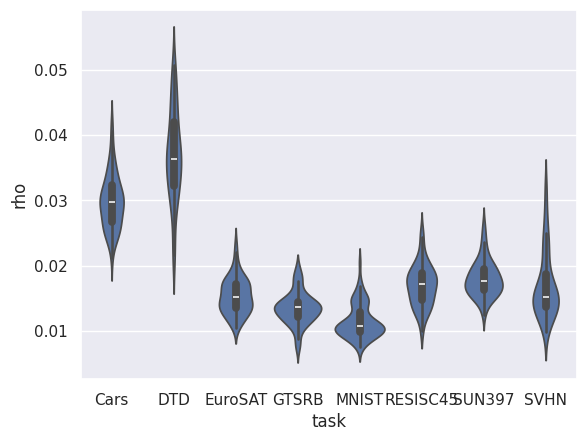

In [ ]:
# # Compute mean per task, layer, entry group
# df_mean = df.groupby(['task', 'layer'])['rho'].mean().reset_index()
# sns.violinplot(data=df_mean, x="task", y="rho")

/tmp/ipykernel_3195366/3840623872.py:74: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  summary_flat = summary.stack(level=0).reset_index()


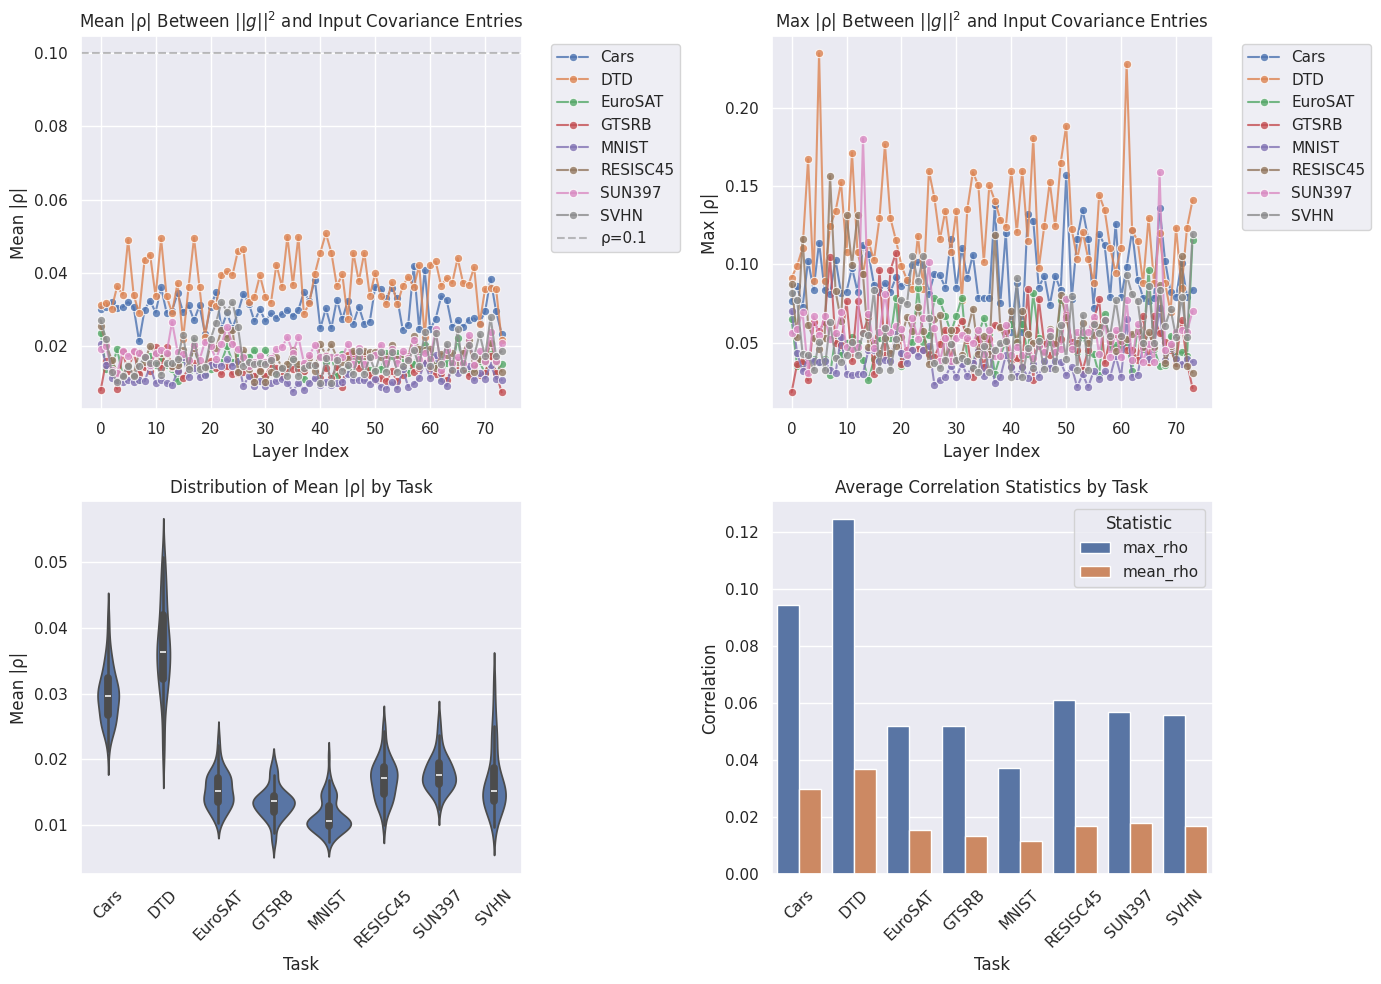


Summary Statistics:
         mean_rho        max_rho       
             mean    max    mean    max
task                                   
Cars        0.030  0.042   0.094  0.157
DTD         0.037  0.051   0.125  0.235
EuroSAT     0.015  0.023   0.052  0.116
GTSRB       0.013  0.020   0.052  0.107
MNIST       0.011  0.020   0.037  0.072
RESISC45    0.017  0.025   0.061  0.156
SUN397      0.018  0.027   0.057  0.180
SVHN        0.017  0.032   0.056  0.119

Overall Statistics:
Global mean |ρ|: 0.020
Global max |ρ|: 0.235
% layers with mean |ρ| < 0.1: 100.0%


In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

sns.set_theme()

model = "ViT-B-16"
results_dir = f"../results/{model}"
tasks = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]
ignore = ["ln_", "ls_", "conv", "patch_dropout"]

corr = lambda x, y: np.corrcoef(x, y)[0, 1] if x.std() > 0 and y.std() > 0 else 0.0

rows = []
for task in tasks:
    path = f"{results_dir}/decorrelation_{task}.npz"
    if not os.path.exists(path):
        continue
    data = np.load(path)
    layers = sorted(k[5:] for k in data.files if k.startswith("g_sq/"))
    layers = [l for l in layers if not any(ig in l for ig in ignore)]

    for idx_l, l in enumerate(layers):
        g, aat = data[f"g_sq/{l}"], data[f"aat_samples/{l}"]
        N_samples, N_indices = aat.shape
        
        # Compute correlations for all indices
        rhos = [np.abs(corr(g, aat[:, idx_i])) for idx_i in range(N_indices)]
        
        # Aggregate statistics per layer
        rows.append({
            'task': task, 
            'layer': l, 
            'layer_idx': idx_l, 
            'mean_rho': np.mean(rhos),
            'max_rho': np.max(rhos),
            'median_rho': np.median(rhos),
            'std_rho': np.std(rhos)
        })

df = pd.DataFrame(rows)

# Create multi-panel plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Mean correlation by layer
sns.lineplot(data=df, x="layer_idx", y="mean_rho", hue="task", 
             marker="o", ax=axes[0, 0], alpha=0.8)
axes[0, 0].set_title("Mean |ρ| Between $||g||^2$ and Input Covariance Entries")
axes[0, 0].set_xlabel("Layer Index")
axes[0, 0].set_ylabel("Mean |ρ|")
axes[0, 0].axhline(0.1, color='gray', linestyle='--', alpha=0.5, label='ρ=0.1')
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 2: Max correlation by layer
sns.lineplot(data=df, x="layer_idx", y="max_rho", hue="task", 
             marker="o", ax=axes[0, 1], alpha=0.8)
axes[0, 1].set_title("Max |ρ| Between $||g||^2$ and Input Covariance Entries")
axes[0, 1].set_xlabel("Layer Index")
axes[0, 1].set_ylabel("Max |ρ|")
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 3: Distribution across all tasks
sns.violinplot(data=df, x="task", y="mean_rho", ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Mean |ρ| by Task")
axes[1, 0].set_xlabel("Task")
axes[1, 0].set_ylabel("Mean |ρ|")
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Summary statistics
summary = df.groupby('task')[['mean_rho', 'max_rho']].agg(['mean', 'std'])
summary_flat = summary.stack(level=0).reset_index()
summary_flat.columns = ['task', 'metric', 'mean', 'std']
sns.barplot(data=summary_flat, x='task', y='mean', hue='metric', ax=axes[1, 1])
axes[1, 1].set_title("Average Correlation Statistics by Task")
axes[1, 1].set_xlabel("Task")
axes[1, 1].set_ylabel("Correlation")
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title='Statistic')

plt.tight_layout()
plt.savefig(f"{results_dir}/decorrelation_analysis.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(df.groupby('task')[['mean_rho', 'max_rho']].agg(['mean', 'max']).round(3).to_string())

print("\nOverall Statistics:")
print(f"Global mean |ρ|: {df['mean_rho'].mean():.3f}")
print(f"Global max |ρ|: {df['max_rho'].max():.3f}")
print(f"% layers with mean |ρ| < 0.1: {(df['mean_rho'] < 0.1).mean() * 100:.1f}%")

## Covariance estimation

In [46]:
class OnlineCovariance:
    def __init__(self, dim1, dim2=1):
        self.meanx = torch.zeros((dim1, dim2))
        self.meany = torch.zeros((dim1, dim2))
        self.C = torch.zeros((dim1, dim1))
        self.n = 0

    @property
    def cov(self):
        # Population covariance
        return self.C / self.n

    @property
    def cov_sample(self):
        # Sample covariance
        return self.C / (self.n - 1)

    def add(self, x, y):
        # goes to the add.
        self.n += 1
        self.dx = x - self.meanx
        self.meanx += self.dx / self.n
        self.meany += (y - self.meany) / self.n
        self.C += self.dx @ (y - self.meany).T


def exact_covariance(X, Y):
    """
    X: (N, D1, D2)
    Y: (N, D1, D2)
    """
    Xc = X - X.mean(dim=0)
    Yc = Y - Y.mean(dim=0)
    C = torch.bmm(Xc, Yc.transpose(1, 2)).mean(dim=0)
    return C


dim1, dim2 = 32, 4
X = torch.randn(10, dim1, dim2)
Y = torch.randn(10, dim1, dim2)

C_exact = exact_covariance(X, Y)

# Compute the covariance using the OnlineCovarianceGeneral class
oc = OnlineCovariance(dim1, dim2)
for x, y in zip(X, Y):
    oc.add(x, y)
C_online = oc.cov

# Compare the two
print("Exact and online functions match:", torch.allclose(C_exact, C_online, atol=1e-6))


Exact and online functions match: True


Loading covariance from: ../results/ViT-B-16/covariance_Cars.npz


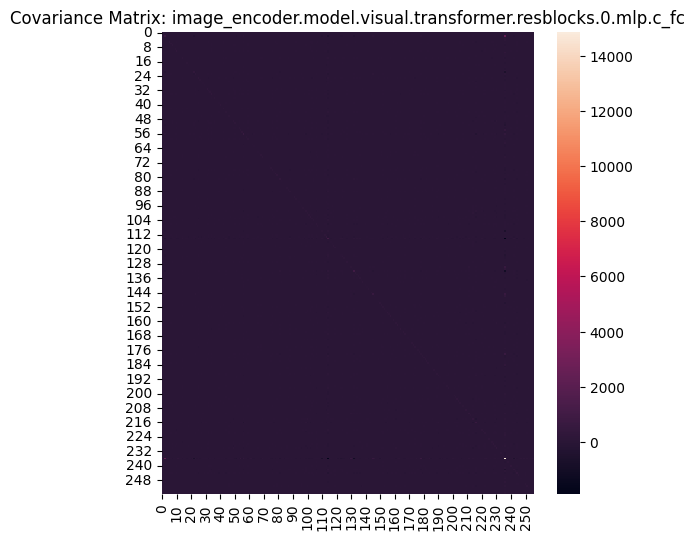

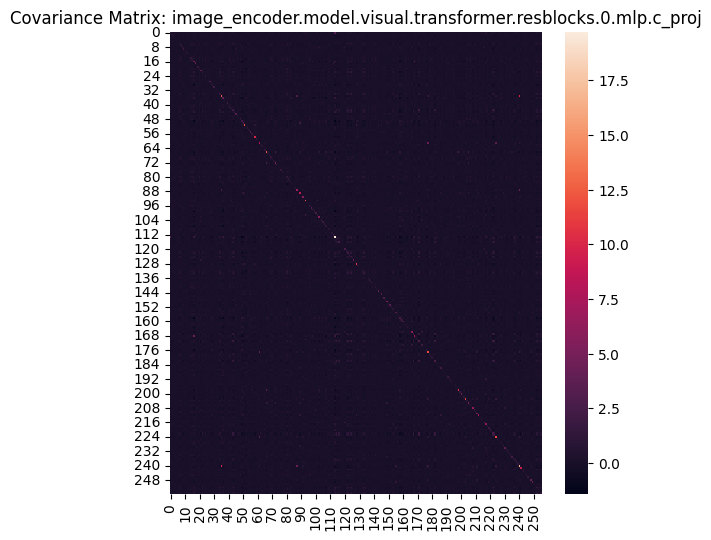

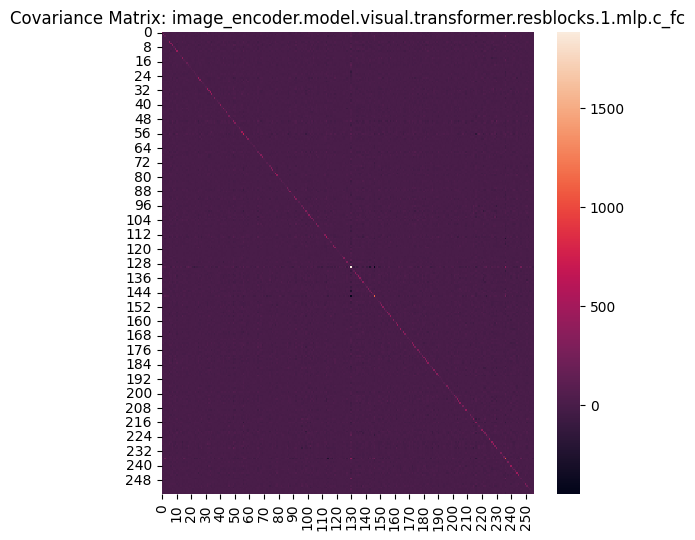

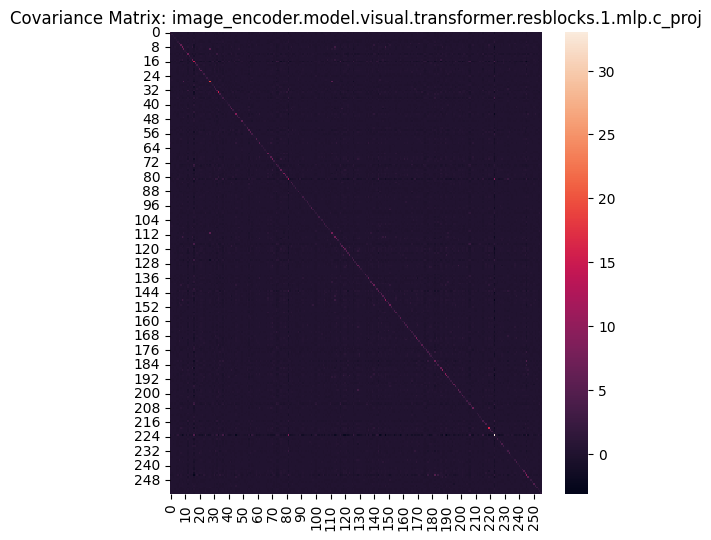

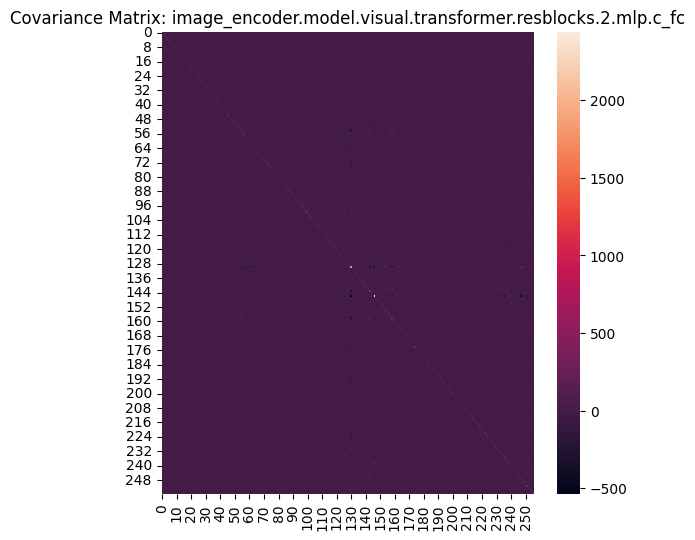

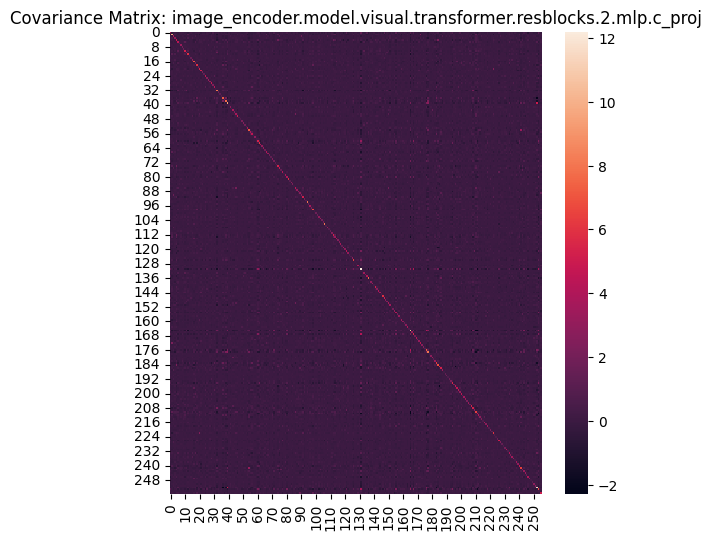

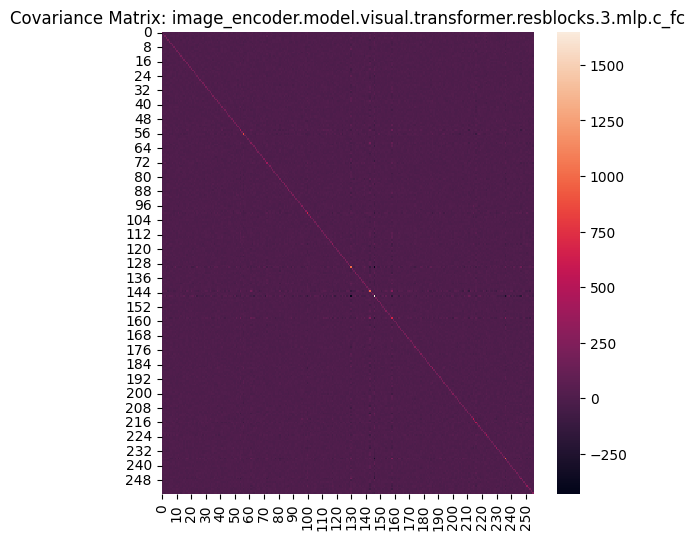

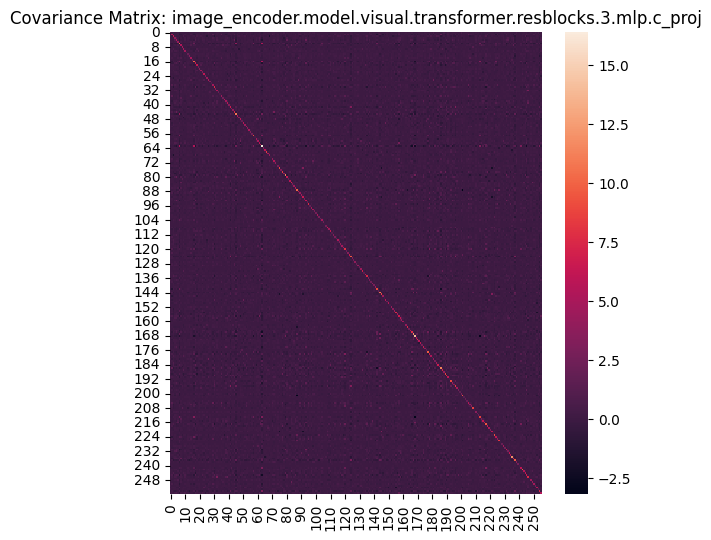

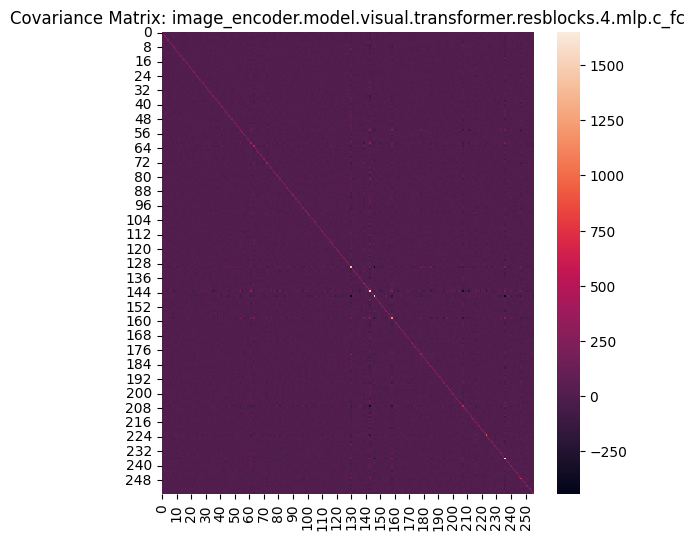

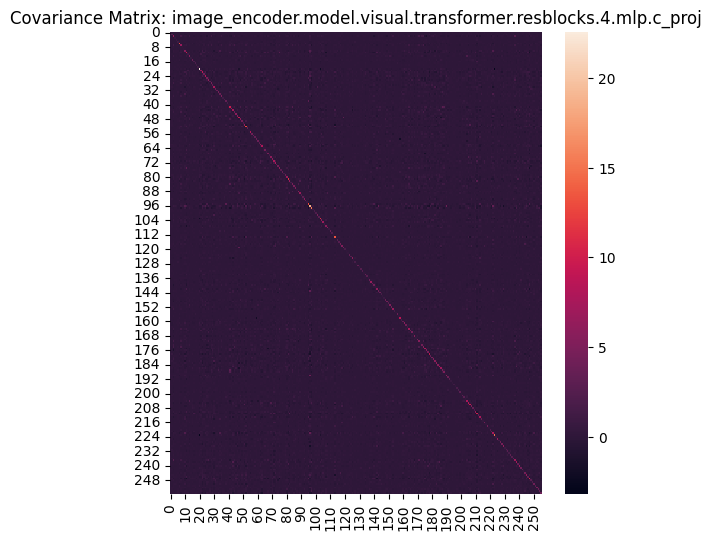

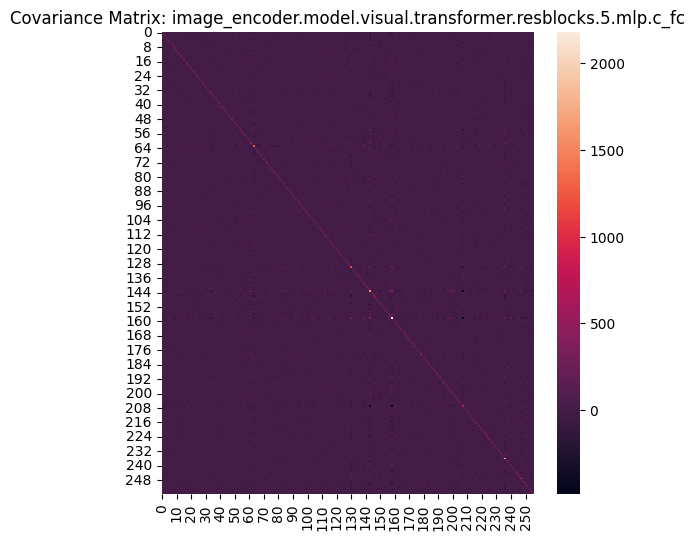

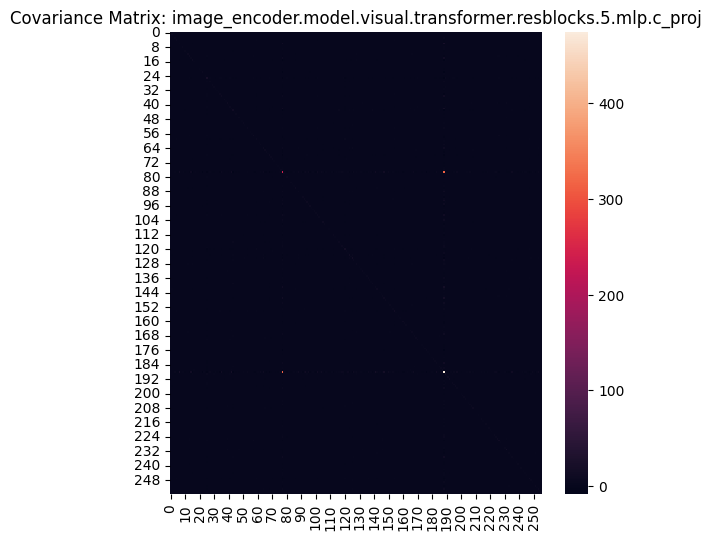

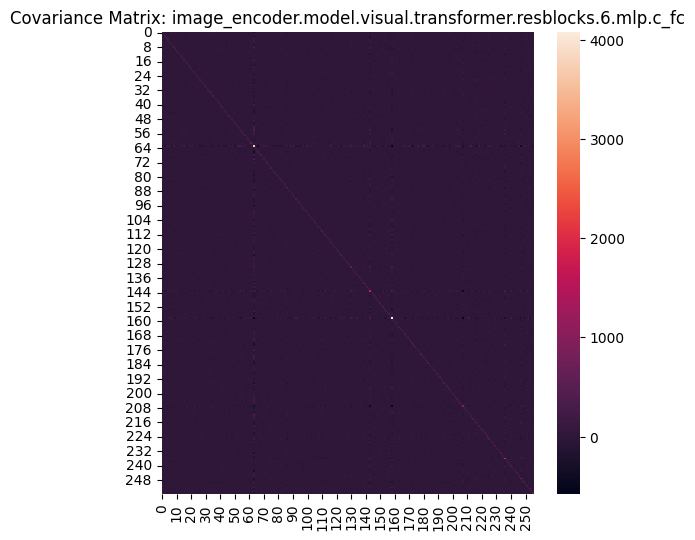

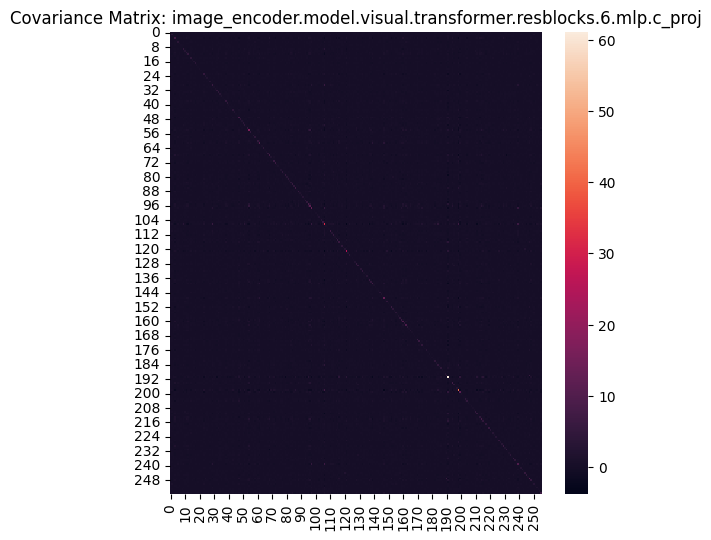

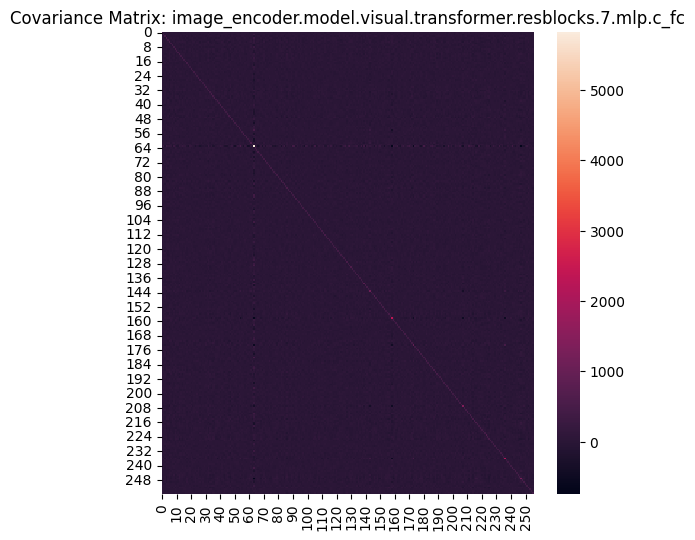

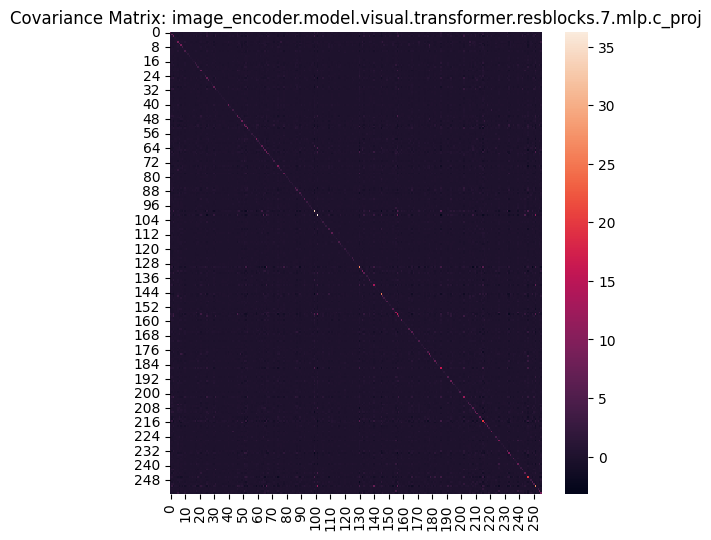

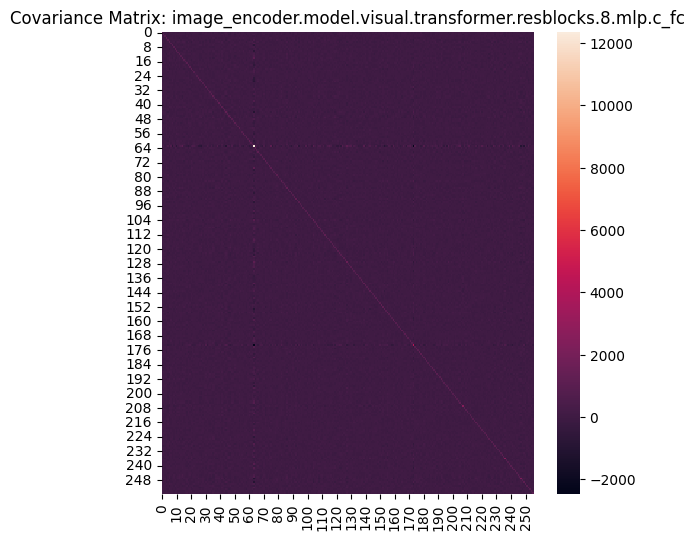

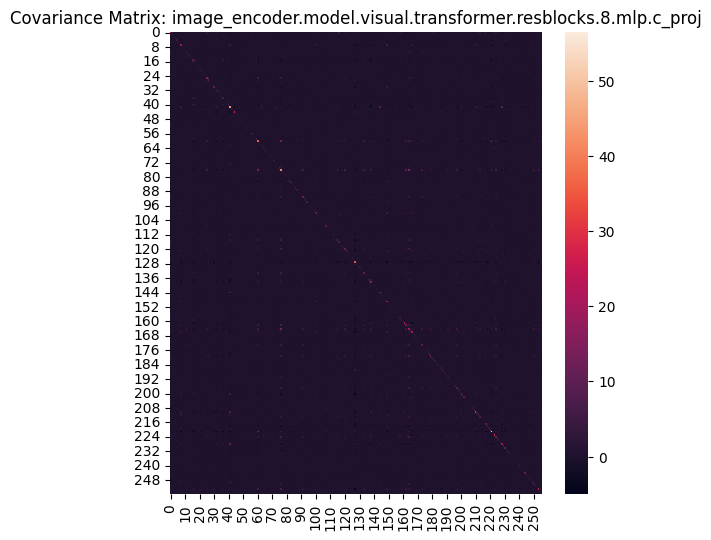

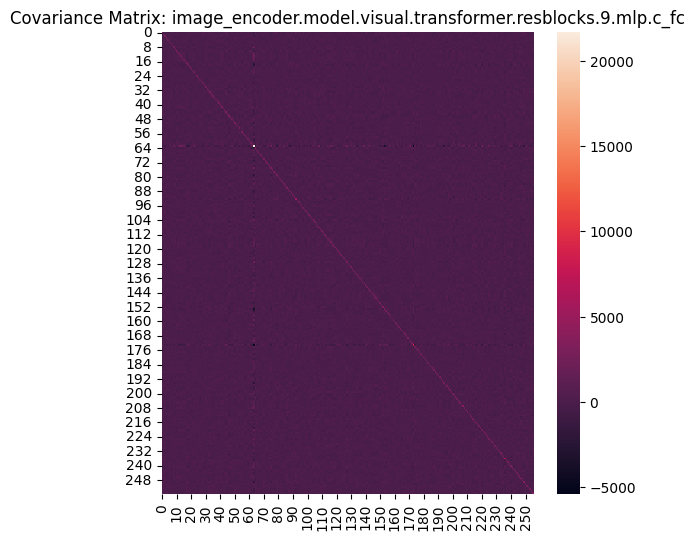

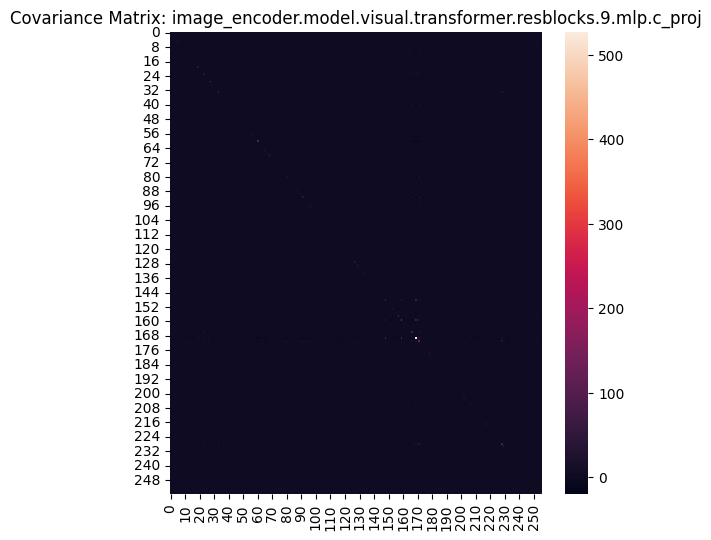

In [ ]:
# Covariance visualization for covariance.py outputs

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path template for covariance files produced by scripts/covariance.py
model = "ViT-B-16"  # change if you used a different model
task = "Cars"     # e.g. "Cars", "MNIST", "RESISC45", ...
max_dim = 256
max_plots = 20
cov_path = f"../results/{model}/covariance_{task}.npz"
print(f"Loading covariance from: {cov_path}")


cov_data = np.load(cov_path)
for i, k in enumerate(cov_data.keys()):
    if i >= max_plots:
        break
    
    # Create a fresh, new figure for every single matrix
    plt.figure(figsize=(6, 6))
    cov_matrix = cov_data[k]
    step = max(1, int(np.ceil(min(cov_matrix.shape) / max_dim)))
    sns.heatmap(cov_matrix[::step, ::step])
    plt.title(f"Covariance Matrix: {k}")
    plt.show()
    # image_encoder.model.visual.transformer.resblocks.11.mlp.c_proj

In [ ]:
# Covariance visualization for covariance.py outputs
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path template for covariance files produced by scripts/covariance.py
model = "ViT-B-16"  # change if you used a different model
task = "Cars"     # e.g. "Cars", "MNIST", "RESISC45", ...
max_dim = 256
max_plots = 20
cov_path = f"../results/{model}/covariance_{task}.npz"
print(f"Loading covariance from: {cov_path}")


cov_data = np.load(cov_path)
for i, k in enumerate(cov_data.keys()):
    print(k)


ModuleNotFoundError: No module named 'matplotlib'

## GPA

In [4]:
import torch
import matplotlib.pyplot as plt
from typing import Union


# def compute_projected_regmean(
#     W: torch.Tensor,
#     Sigma: Union[torch.Tensor, None] = None,
#     max_iter: int = 100,
#     tol: float = 1e-8,
# ):
#     """
#     Solve: min_{W_con, Q_t ortho} sum_t tr[(W_con - Q_t W_t) Sigma (W_con - Q_t W_t)^T]

#     Args:
#         W:       input matrices (T, d_out, d_in)
#         Sigma:   covariance matrix (d_in, d_in), defaults to identity
#         max_iter: max alternating minimization iterations
#         tol:     convergence tolerance on loss change

#     Returns:
#         W_con:  consensus matrix (d_out, d_in)
#         Q:      orthogonal matrices (T, d_out, d_out)
#         losses: list of scalar loss values per iteration
#     """
#     T, d_out, d_in = W.shape
#     device = W.device

#     if Sigma is None:
#         Sigma = torch.eye(d_in, device=device, dtype=W.dtype)

#     W_con = W.mean(dim=0)  # (d_out, d_in)
#     losses = []

#     for iteration in range(max_iter):
#         # --- Update Q: orthogonal Procrustes ---
#         # max_{Q_t} tr(Q_t W_t Sigma W_con^T)  =>  Q_t = V U^T
#         M = W @ Sigma @ W_con.T          # (T, d_out, d_out)
#         U, _, Vh = torch.linalg.svd(M)  # (T, d_out, d_out) each
#         Q = Vh.mT @ U.mT               # (T, d_out, d_out)

#         # --- Update W_con: mean of rotated matrices ---
#         W_con = (Q @ W).mean(dim=0)    # (d_out, d_in)

#         # --- Loss: sum_t tr[(W_con - Q_t W_t) Sigma (W_con - Q_t W_t)^T] ---
#         residuals = W_con.unsqueeze(0) - Q @ W  # (T, d_out, d_in)
#         loss = torch.einsum("toi,ij,toj->", residuals, Sigma, residuals).item()
#         losses.append(loss)

#         if iteration > 0 and abs(losses[-2] - losses[-1]) < tol:
#             print(f"Converged at iteration {iteration}")
#             break

#     return W_con, Q, losses


def loss_projected_regmean(w_star, q, w, c):
    """Compute projected regmean loss.



    .. math::
        sum_t Tr[(w_star - q_t w_t) c (w_star - q_t w_t)^T]
    
    Args:
        w_star: (Do, Di) - consensus matrix
        q: (N, Do, Do) - orthogonal matrices
        w: (N, Do, Di) - input matrices
        c: (N, Di, Di) - covariance matrix
        
    Returns:
        loss: scalar - sum_t tr[(w_star - q_t w_t) sigma (w_star - q_t w_t)^T]
    """
    residuals = w_star.unsqueeze(0) - q @ w # (N, Do, Di)
    # Tr[(w_star - q_t w_t) c (w_star - q_t w_t)^T]
    return torch.einsum("noi,nij,njo->", residuals, c, residuals.transpose(1, 2))


def loss_regmean(w_star, w, c):
    """Compute regmean loss.
    Args:
        w_star: (Do, Di)
        w: (N, Do, Di)
        c: (N, Di, Di) 
    """
    residuals = w_star.unsqueeze(0) - w  # (N, Do, Di)
    return torch.einsum("noi,nij,njo->", residuals, c, residuals.transpose(1, 2))


def compute_projected_regmean(w, c_train=None, c_test=None, max_iter=100, tol=1e-8):
    """Solve: min_{w_con, q_t ortho} sum_t tr[(w_con - q_t w_t) sigma (w_con - q_t w_t)^T]
    
    Args:
        w: (N, Do, Di) - input matrices
        c: (N, Di, Di) - covariance matrix (defaults to identity)
        max_iter: maximum alternating minimization iterations
        tol: convergence tolerance on loss change
        
    Returns:
        w_star: (Do, Di) - consensus matrix
        q: (N, Do, Do) - orthogonal matrices
        losses: list of scalar loss values per iteration
    """
    N, Do, Di = w.shape
    
    if c_train is None:
        c_train = torch.eye(Di, device=w.device, dtype=w.dtype).unsqueeze(0).expand(N, -1, -1)
    if c_test is None:
        c_test = torch.eye(Di, device=w.device, dtype=w.dtype).unsqueeze(0).expand(N, -1, -1)
    
    w_star = w.mean(dim=0)
    losses = []

    c_sum_pinv = torch.linalg.pinv(c_train.sum(dim=0))
    
    for iteration in range(max_iter):
        # Update q mats: orthogonal Procrustes
        u, _, vt =  torch.linalg.svd(w_star @ c_train @ w.transpose(1, 2), full_matrices=False)
        q_star = u @ vt  # (N, Do, Di)
        
        # Update w_star: mean of rotated matrices
        w_star = (q_star @ w @ c_train).sum(dim=0) @ c_sum_pinv
        
        # Compute loss
        loss = loss_projected_regmean(w_star, q_star, w, c_test)
        losses.append(loss.item())
        
        if iteration > 0 and abs(losses[-2] - losses[-1]) < tol:
            break
    
    return w_star, q_star, losses

def compute_regmean(w, c_train=None, c_test=None):
    if c_train is None:
        c_train = torch.eye(Di, device=w.device, dtype=w.dtype).unsqueeze(0).expand(N, -1, -1)
    if c_test is None:
        c_test = torch.eye(Di, device=w.device, dtype=w.dtype).unsqueeze(0).expand(N, -1, -1)
    w_star = (w @ c_train).sum(dim=0) @ torch.linalg.pinv(c_train.sum(dim=0))
    return w_star, loss_regmean(w_star, w, c_test)


# --- Demo ---
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    torch.manual_seed(42)
    N, Do, Di = 3, 8, 32

    w_true = torch.randn(Do, Di, device=device)
    w = w_true.unsqueeze(0) + 0.1 * torch.randn(N, Do, Di, device=device)

    a = torch.randn(N, Di, Di, device=device)
    cov_matrix = a @ a.transpose(1, 2) / Di + torch.eye(Di, device=device).unsqueeze(0)

    w_star_prm, q_star_prm, losses_prm = compute_projected_regmean(w, c_test=cov_matrix, c_train=cov_matrix)
    w_star_rm, loss_rm = compute_regmean(w, c_train=cov_matrix, c_test=cov_matrix)
    print(f"Loss (PRM): {losses_prm[-1]:.2f}")
    print(f"Loss (RM): {loss_rm:.2f}")

Using device: cpu
Loss (PRM): 8.54
Loss (RM): 9.92
